In [1]:
# Load libs
import numpy as np
import pandas as pd
import h5py
import glob
import os
from scipy.signal import butter, filtfilt
from scipy.io import loadmat
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit, ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, precision_recall_curve, roc_curve, roc_auc_score, fbeta_score
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

device = 'cuda'

# CWRU

## Load and split data

In [107]:
path_input = 'CWRU/processed_features/all_features.csv'
df = pd.read_csv(path_input)

In [108]:
df['meta_fname'].unique()

array(['Ball007_1730', 'Ball007_1750', 'Ball007_1772', 'Ball007_1797',
       'IR007_1730', 'IR007_1750', 'IR007_1772', 'IR007_1797',
       'Normal_1730', 'Normal_1750', 'Normal_1772', 'Normal_1797',
       'OR007_1730', 'OR007_1750', 'OR007_1772', 'OR007_1797'],
      dtype=object)

In [109]:
# Для облегчения разметим дополнительно нормальные данные
df['is_normal'] = df['meta_fname'].str.startswith('Normal').astype(bool)

# Разделяем на нормальные и дефектные
normal_data = df[df['is_normal']].copy()
defective_data = df[df['is_normal'] == False].copy()

In [110]:
# check
print('Normal:', normal_data.meta_fname.unique())
print('Defective:', defective_data.meta_fname.unique())

Normal: ['Normal_1730' 'Normal_1750' 'Normal_1772' 'Normal_1797']
Defective: ['Ball007_1730' 'Ball007_1750' 'Ball007_1772' 'Ball007_1797' 'IR007_1730'
 'IR007_1750' 'IR007_1772' 'IR007_1797' 'OR007_1730' 'OR007_1750'
 'OR007_1772' 'OR007_1797']


### Разделяем нормальные данные: 70% train, 15% val, 15% test

In [111]:
# Отделяем на train (70%) и temp (30%)
sss1 = StratifiedShuffleSplit(n_splits=1, train_size=0.7, random_state=0)
    
for train_idx, temp_idx in sss1.split(normal_data, normal_data['meta_fname']):
    train_normal = normal_data.iloc[train_idx].copy()
    temp_normal = normal_data.iloc[temp_idx].copy()
    
# Делим temp на val и test (50/50)
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=0.5, random_state=0)
    
for val_idx, test_idx in sss2.split(temp_normal, temp_normal['meta_fname']):
    val_normal = temp_normal.iloc[val_idx].copy()
    test_normal = temp_normal.iloc[test_idx].copy()

In [112]:
print(f"Train (60%): {len(train_normal)}")
print(f"Validation (15%): {len(val_normal)}")
print(f"Test (15%): {len(test_normal)}")

print(f"\nTrain strats:\n{train_normal.meta_fname.value_counts()}")
print(f"\nVal strats:\n{val_normal.meta_fname.value_counts()}")
print(f"\nTest strats:\n{test_normal.meta_fname.value_counts()}")

Train (60%): 2318
Validation (15%): 497
Test (15%): 497

Train strats:
meta_fname
Normal_1730    663
Normal_1750    662
Normal_1772    661
Normal_1797    332
Name: count, dtype: int64

Val strats:
meta_fname
Normal_1750    142
Normal_1730    142
Normal_1772    141
Normal_1797     72
Name: count, dtype: int64

Test strats:
meta_fname
Normal_1750    142
Normal_1730    142
Normal_1772    142
Normal_1797     71
Name: count, dtype: int64


### Разделяем данные о дефектных подшипниках: 10% val, 90% test

По сути использование меток в val делает подход semi-supervised, но зато мы можем подобрать гиперпараметры. Отметим, что в валидационной выборке используем маленькую часть аномалий.

In [113]:
sss_defect = StratifiedShuffleSplit(n_splits=1, train_size=0.1, random_state=0)
    
for val_idx, test_idx in sss_defect.split(defective_data, defective_data['meta_fname']):
    val_defective = defective_data.iloc[val_idx].copy()
    test_defective = defective_data.iloc[test_idx].copy()

In [114]:
print(f"Validation (10%): {len(val_defective)}")
print(f"Test (90%): {len(test_defective)}")

print(f"\nVal strats:\n{val_defective.meta_fname.value_counts()}")
print(f"\nTest strats:\n{test_defective.meta_fname.value_counts()}")

Validation (10%): 284
Test (90%): 2559

Val strats:
meta_fname
OR007_1772      24
Ball007_1797    24
IR007_1750      24
Ball007_1730    24
IR007_1730      24
OR007_1730      24
OR007_1797      24
IR007_1772      24
Ball007_1750    23
IR007_1797      23
OR007_1750      23
Ball007_1772    23
Name: count, dtype: int64

Test strats:
meta_fname
IR007_1730      215
OR007_1730      214
Ball007_1797    214
OR007_1772      214
OR007_1797      213
IR007_1772      213
Ball007_1772    213
Ball007_1750    213
OR007_1750      213
IR007_1750      213
IR007_1797      212
Ball007_1730    212
Name: count, dtype: int64


### Выборки и разметка

В качестве меток будем использовать -1 для аномалии и 1 для нормы. Такой вариант разметки выбран для согласования с sklearn (isolation forest и OCSVM определяют является ли образец inlier (+1) или outlier (-1)).

In [115]:
# Обучающая выборка - только нормальные (метки не нужны)
X_train = train_normal.drop(columns=['is_normal', 'meta_fname'])
X_train = shuffle(X_train, random_state=0)

# Валидационная - нормальные и деффектные
val_df = pd.concat([val_normal, val_defective], ignore_index=True)
val_df = shuffle(val_df, random_state=0)
X_val = val_df.drop(columns=['is_normal', 'meta_fname'])
y_val = np.where(val_df['is_normal'], 1, -1)

# Тестовая - нормальные и деффектные
test_df = pd.concat([test_normal, test_defective], ignore_index=True)
test_df = shuffle(test_df, random_state=0)
X_test = test_df.drop(columns=['is_normal', 'meta_fname'])
y_test = np.where(test_df['is_normal'], 1, -1)

In [116]:
# Оценка баланса классов в тестовой выборке
np.unique(y_test, return_counts=True)

(array([-1,  1]), array([2559,  497]))

Заметное смещение в тестовой выборке в пользу класса аномалий.

### Нормализация и PCA

Нормализация признаков:

In [117]:
feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled =  feature_scaler.transform(X_test)

PCA с сохранение 95% дисперсии:

In [118]:
pca = PCA(n_components=0.95, random_state=0)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [119]:
sum(pca.explained_variance_ratio_)

np.float64(0.9573746357827385)

In [120]:
pca.n_components_

np.int64(17)

## Isolation Forest

In [16]:
iso_forest = IsolationForest(random_state=0)

iso_forest.fit(X_train_pca)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,0
,verbose,0
,warm_start,False


In [21]:
test_predictions = iso_forest.predict(X_test_pca)

# Метрики на валидационной выборке
print("test scores:")
print(f"F1-score: {f1_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"Precision: {precision_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test, test_predictions, beta=2.0, pos_label=-1):.4f}')

test scores:
F1-score: 0.9975
Precision: 0.9949
Recall: 1.0000
F-beta score: 0.9990


### Подбор гиперпараметров с помощью GridSearch:

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': ['auto', 0.5, 0.7],
    'contamination': [0.01, 0.05, 0.1, 0.15, 'auto'],
    'max_features': [0.5, 0.7, 1.0],
    'bootstrap': [False, True]
}

results = []

for params in tqdm(ParameterGrid(param_grid)):
    iso_forest = IsolationForest(random_state = 0, **params)
    iso_forest.fit(X_train_pca)

    val_pred = iso_forest.predict(X_val_pca)

    f1 = f1_score(y_val, val_pred, pos_label=-1)
    precision = precision_score(y_val, val_pred, pos_label=-1)
    recall = recall_score(y_val, val_pred, pos_label=-1)
    fbeta = fbeta_score(y_val, val_pred, beta=2.0, pos_label=-1)

    results.append({
        **params,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'fbeta': fbeta
    })

# Сортируем результаты
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('fbeta', ascending=False)

  0%|          | 0/270 [00:00<?, ?it/s]

In [23]:
results_df.head(5)

,bootstrap,contamination,max_features,max_samples,n_estimators,f1,precision,recall,fbeta
6,False,0.01,0.5,0.7,100,0.998243,0.996491,1.0,0.999296
5,False,0.01,0.5,0.5,300,0.998243,0.996491,1.0,0.999296
4,False,0.01,0.5,0.5,200,0.998243,0.996491,1.0,0.999296
3,False,0.01,0.5,0.5,100,0.998243,0.996491,1.0,0.999296
10,False,0.01,0.7,auto,200,0.998243,0.996491,1.0,0.999296


In [25]:
iso_forest = IsolationForest(
    contamination=0.01,
    random_state=0,
    max_features =0.5,
    bootstrap=False,
    max_samples=0.7,
    n_estimators=100
)

iso_forest.fit(X_train_pca)
test_predictions = iso_forest.predict(X_test_pca)

# Метрики на тестовой выборке
print("Test scores:")
print(f"F1-score: {f1_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"Precision: {precision_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test, test_predictions, beta=2.0, pos_label=-1):.4f}')

Test scores:
F1-score: 0.9996
Precision: 0.9992
Recall: 1.0000
F-beta score: 0.9998


## OCSVM

In [26]:
ocsvm = OneClassSVM()

ocsvm.fit(X_train_pca)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,nu,0.5
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [27]:
test_predictions = ocsvm.predict(X_test_pca)

# Метрики на валидационной выборке
print("test scores:")
print(f"Precision: {precision_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"F1-score: {f1_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test, test_predictions, beta=2.0, pos_label=-1):.4f}')

test scores:
Precision: 0.9149
Recall: 1.0000
F1-score: 0.9556
F-beta score: 0.9817


### Подбор гиперпараметров с помощью GridSearch:

In [34]:
# Только rbf ядро (25 комбинаций)
param_grid_rbf = {
    'kernel': ['rbf'],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
}

# Только poly ядро (225 комбинаций)
param_grid_poly = {
    'kernel': ['poly'],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'degree': [3, 4, 5],
    'coef0': [0.0, 0.1, 0.5],
}

# Только sigmoid ядро (50 комбинации)
param_grid_sigmoid = {
    'kernel': ['sigmoid'],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'coef0': [0.0, 0.1],
}

param_grid_ocsvm = [param_grid_rbf, param_grid_poly, param_grid_sigmoid]

results_ocsvm = []

for params in tqdm(ParameterGrid(param_grid_ocsvm)):
    ocsvm = OneClassSVM(**params)
    ocsvm.fit(X_train_pca)

    val_pred = ocsvm.predict(X_val_pca)

    f1 = f1_score(y_val, val_pred, pos_label=-1)
    precision = precision_score(y_val, val_pred, pos_label=-1)
    recall = recall_score(y_val, val_pred, pos_label=-1)
    fbeta = fbeta_score(y_val, val_pred, beta=2.0, pos_label=-1)

    results_ocsvm.append({
        **params,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'fbeta': fbeta
    })

# Сортируем результаты
results_ocsvm_df = pd.DataFrame(results_ocsvm)
results_ocsvm_df = results_ocsvm_df.sort_values('fbeta', ascending=False)

  0%|          | 0/300 [00:00<?, ?it/s]

In [35]:
results_ocsvm_df.head(5)

,gamma,kernel,nu,f1,precision,recall,fbeta,coef0,degree
20,0.001,rbf,0.01,0.998243,0.996491,1.0,0.999296,NaN,NaN
15,0.01,rbf,0.01,0.989547,0.979310,1.0,0.995792,NaN,NaN
175,scale,poly,0.01,0.975945,0.953020,1.0,0.990237,0.5,3.0
115,0.01,poly,0.01,0.975945,0.953020,1.0,0.990237,0.1,3.0
180,auto,poly,0.01,0.970940,0.943522,1.0,0.988170,0.5,3.0


In [36]:
ocsvm = OneClassSVM(gamma=0.001, kernel='rbf', nu=0.01)

ocsvm.fit(X_train_pca)

test_predictions = ocsvm.predict(X_test_pca)

# Метрики на тестовой выборке
print("Test scores:")
print(f"Precision: {precision_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f"F1-score: {f1_score(y_test, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test, test_predictions, beta=2.0, pos_label=-1):.4f}')

Test scores:
Precision: 0.9977
Recall: 1.0000
F1-score: 0.9988
F-beta score: 0.9995


## Autoencoder

Для обучения автоэнкодера необходима val выборка без меток (тоже нормальное состояние, а не как в других моделях). Валидационная выборка с аномалиями будет использоваться для подбора порога срабатывания.

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=8):
        super(Autoencoder, self).__init__()
        
        # Энкодер
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ELU(),
            
            nn.Linear(32, 24),
            nn.BatchNorm1d(24),
            nn.ELU(),

            nn.Linear(24, 16),
            nn.BatchNorm1d(16),
            nn.ELU(),
            
            nn.Linear(16, encoding_dim),
            nn.ELU()
        )
        
        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.BatchNorm1d(16),
            nn.ELU(),
            
            nn.Linear(16, 24),
            nn.BatchNorm1d(24),
            nn.ELU(),

            nn.Linear(24, 32),
            nn.BatchNorm1d(32),
            nn.ELU(),
            
            nn.Linear(32, input_dim),
            nn.Identity()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [15]:
def compute_reconstruction_error(model, dataloader, threshold=None):
    model.eval()
    model = model.to(device)
    
    reconstruction_errors = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            if len(batch) == 2:
                X, y = batch
                all_labels.extend(y.numpy())
            else:
                X = batch[0]
            
            X = X.to(device)
            X_pred = model(X)
            
            # Вычисляем MSE для каждого образца
            mse = torch.mean((X_pred - X) ** 2, dim=1)
            reconstruction_errors.extend(mse.cpu().numpy())
    
    reconstruction_errors = np.array(reconstruction_errors)
    
    # Если задан порог, делаем предсказания
    if threshold is not None:
        y_true = np.array(all_labels)
        predictions = np.where(reconstruction_errors > threshold, -1, 1)
        
        if len(all_labels) > 0:
            precision = precision_score(y_true, predictions, pos_label=-1)
            recall = recall_score(y_true, predictions, pos_label=-1)
            f1 = f1_score(y_true, predictions, pos_label=-1)
            fbeta = fbeta_score(y_true, predictions, beta=2.0, pos_label=-1)
            
            return reconstruction_errors, predictions, {
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'fbeta': fbeta
            }
        return reconstruction_errors, predictions
    
    return reconstruction_errors

In [16]:
def find_optimal_threshold(model, dataloader, y_val, percentiles=[95, 97, 98, 99, 99.5, 99.9]):
    reconstruction_errors = compute_reconstruction_error(model, dataloader)
    
    results = []
    
    for percentile in percentiles:
        threshold = np.percentile(reconstruction_errors[y_val == 1], percentile)
        _, _, metrics = compute_reconstruction_error(model, dataloader, threshold)
        
        results.append({
            'percentile': percentile,
            'threshold': threshold,
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'fbeta': metrics['fbeta']
        })
    
    # Сортируем по F1
    results_df = pd.DataFrame(results)
    best_idx = results_df['fbeta'].idxmax()
    
    return results_df, results_df.loc[best_idx]

In [128]:
# Разделяем обучающие данные на train (80%) и validation (20%)
X_train_normal, X_val_normal = train_test_split(
    X_train_pca, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

# datasets and dataloaders
train_dataset = TensorDataset(torch.FloatTensor(X_train_normal))
val_dataset = TensorDataset(torch.FloatTensor(X_val_normal))
test_dataset = TensorDataset(torch.FloatTensor(X_test_pca), torch.LongTensor(np.array(y_test)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
# Создание модели и её обучение
model = Autoencoder(len(X_train_pca[0])).to(device)
criterion = nn.MSELoss()
criterion_mae = nn.L1Loss()
optimizer = optim.Adam(model.parameters())

history = {
    'train_loss': [], 'train_mae': [],
    'val_loss': [], 'val_mae': []
}

# Early Stopping
best_val_loss = float('inf')
patience_counter = 0
patience = 15

epoch_pbar = tqdm(range(100), desc='Эпохи')

for epoch in epoch_pbar:
    # train
    model.train()
    train_loss = 0.0
    train_mae = 0.0

    for batch in train_loader:
        X = batch[0].to(device)
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, X)
        mae = criterion_mae(output, X)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
        train_mae += mae.item() * X.size(0)

    train_loss /= len(train_loader.dataset)
    train_mae /= len(train_loader.dataset)
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)

    # val
    model.eval()
    val_loss = 0.0
    val_mae = 0.0

    with torch.no_grad():
        for batch in val_loader:
            X = batch[0].to(device)
            output = model(X)
            loss = criterion(output, X)
            mae = criterion_mae(output, X)

            val_loss += loss.item() * X.size(0)
            val_mae += mae.item() * X.size(0)

    val_loss /= len(val_loader.dataset)
    val_mae /= len(val_loader.dataset)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    epoch_pbar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'train_mae': f'{train_mae:.4f}',
        'val_loss': f'{val_loss:.4f}',
        'val_mae': f'{val_mae:.4f}'
    })
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'saved_models/best_ae_cwru.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch+1}")
            break

Эпохи:   0%|          | 0/100 [00:00<?, ?it/s]


Ранняя остановка на эпохе 94


<Axes: >

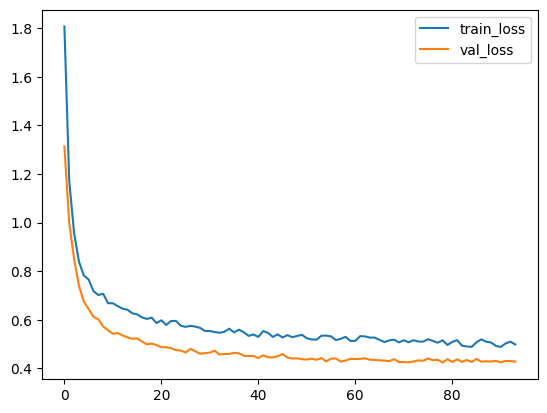

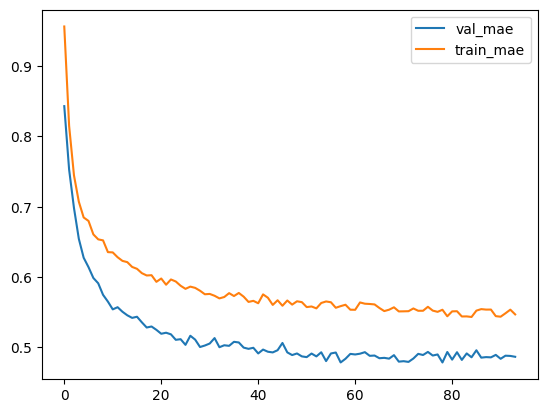

In [21]:
# Кривые обучения
history_df = pd.DataFrame(history)
history_df.loc[:, ['train_loss', 'val_loss']].plot()
history_df.loc[:, ['val_mae', 'train_mae']].plot()

In [22]:
# загрузка лучшей модели
model = Autoencoder(len(X_train_pca[0])).to(device)
model.load_state_dict(torch.load('saved_models/best_ae_cwru.pth'))

<All keys matched successfully>

In [23]:
# Использование валидационной выборки для определения порога срабатывания
val1_dataset = TensorDataset(torch.FloatTensor(X_val_pca), torch.LongTensor(np.array(y_val)))
val1_loader = DataLoader(val1_dataset, batch_size=32, shuffle=False)
threshold_results, best_threshold = find_optimal_threshold(model, val1_loader, y_val)

In [24]:
threshold_results.sort_values('f1', ascending=False)

,percentile,threshold,precision,recall,f1,fbeta
5,99.9,1.453361,0.996491,1.0,0.998243,0.999296
4,99.5,1.178014,0.989547,1.0,0.994746,0.997892
3,99.0,1.036466,0.982699,1.0,0.991274,0.996491
2,98.0,0.920444,0.965986,1.0,0.982699,0.993007
1,97.0,0.860664,0.949833,1.0,0.974271,0.989547
0,95.0,0.816891,0.919094,1.0,0.957841,0.982699


In [25]:
test_errors, test_predictions, test_metrics = compute_reconstruction_error(
    model, 
    test_loader,
    best_threshold['threshold'])

print("\nTest scores:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f"F-beta score: {test_metrics['fbeta']:.4f}")


Test scores:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
F-beta score: 1.0000


# End-to-end DL

## Preprocessing

Будут использованы следующие шаги (аналогичны пайплайну для классического подхода):
1. Чтение данных + разметка.
2. Фильтрация.
3. Сегментация.

In [2]:
def mat_to_df_cwru(mat_file_path: str, use_DE=True, fs: int=12000, verbose: bool=False):
    """
    Функция для чтения данных CWRU из формата .mat.
    """
    if verbose:
        print(f"Чтение: {mat_file_path}")
    
    # Загрузка .mat файла
    mat_data = loadmat(mat_file_path)
    
    # Поиск массива с данными
    data_array = None
    for key in mat_data.keys():
        if not key.startswith('__'): # Пропуск метаданных
            if 'DE' in key and use_DE:
                data_array = mat_data[key].flatten()
            elif 'FE' in key and not use_DE:
                data_array = mat_data[key].flatten()
      
    if data_array is None:
        if verbose:
            print("Ошибка: не найден массив с данными")
        return None
    
    # Создание DataFrame
    df = pd.DataFrame({'Amplitude': data_array})
    
    return df

def filter_signal(data, fs: int = 12000, lowcut: float = 10, highcut: float = 5000, order: int = 4, verbose: bool=False):
    """
    Фильтрация сигнала с помощью полосового фильтра Баттерворта.
    """
    if verbose:
        print(f"Частота дискретизации: {fs} Гц")
        print(f"Полоса пропускания: {lowcut}-{highcut} Гц")
        print(f"Порядок фильтра: {order}")

    # Нормализация частот
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    # Создание фильтра
    b, a = butter(order, [low, high], btype='band')

    # Применение фильтра
    filtered_amplitude = filtfilt(b, a, data['Amplitude'].values)
    filtered_data = pd.DataFrame({
        'Amplitude': filtered_amplitude
    })

    if verbose:
        print(f"Фильтрация завершена.")

    return filtered_data

def segment_signal(data, fs: int=12000, window_size: int=1024, overlap=0.5, verbose: bool=False):
    """
    Сегментация сигнала с перекрытием.
    """
    # Извлечение амлитуд и расчёт шага
    amplitude = data['Amplitude'].values
    step = int(window_size * (1 - overlap))
    
    if verbose:
        print(f"Размер окна: {window_size} отсчетов")
        print(f"Перекрытие: {overlap*100:.0f}%")
        print(f"Шаг: {step} отсчетов")
    
    # Сегментация
    segments_list = []
    
    for i in range(0, len(amplitude) - window_size + 1, step):
        segment = amplitude[i:i + window_size]
        segments_list.append(segment)
    
    # Итоговый массив сегментов (ndarray)
    segments = np.array(segments_list)

    if verbose:
        print(f"Всего сегментов: {len(segments)}")
    
    return segments

In [89]:
mat_files = sorted(glob.glob('CWRU/raw_data/*'))
all_segments = []
all_labels = []

for i, mat_file in enumerate(mat_files):
    # Определение метки по названию файла (Normal/other), 1-anomaly, 0-normal
    filename = Path(mat_file).name
    label = None
    if 'Normal' in filename:
        label = 0
    else:
        label = 1
    
    df = mat_to_df_cwru(mat_file)                       # Чтение
    df_filtered_signal = filter_signal(df)              # Фильтрация
    nd_segments = segment_signal(df_filtered_signal)    # Сегментация
    all_segments.append(nd_segments)                    # Записываем сегменты
    all_labels.append(np.full(len(nd_segments), label)) # Записываем метки

# Объединение всех данных
X = np.vstack(all_segments)
y = np.hstack(all_labels)

# Сохранение данных
current_path = os.path.join('CWRU', 'cwru_labeled.h5')
with h5py.File(current_path, 'w') as f:
    f.create_dataset('data', data=X, compression="gzip", chunks=True)
    f.create_dataset('labels', data=y, compression="gzip")

## Выборки
Нужны выборки:
1. Обучающая + валидационная - для обучения по эпохам (70% норм).
2. Валидация_порога - для подбора порога срабатывания (15% норм и 40% аномалий).
3. Тестовая - для оценки (15% норм и 60% аномалий).

In [100]:
with h5py.File('CWRU/cwru_labeled.h5', 'r') as f:
    X = f['data'][:]
    y = f['labels'][:]
print(f'X shape before: {X.shape}')
X = X.reshape(X.shape[0], X.shape[1], 1)
print(f'X shape after: {X.shape}')

X shape before: (6155, 1024)
X shape after: (6155, 1024, 1)


In [101]:
# Нормальные
X_normal = X[y == 0]
y_normal = y[y == 0]

# Аномалии
X_anomaly = X[y == 1]
y_anomaly = y[y == 1]

# Разделение норм: train+val и test+val_threshold
X_norm_train_val, X_norm_test_val, y_norm_train_val, y_norm_test_val = train_test_split(
    X_normal, y_normal, 
    train_size=0.7,
    random_state=0,
    shuffle=True
)

# 15% норм на подбор порога, 15% норма на тест
X_norm_val_threshold, X_norm_test, y_norm_val_threshold, y_norm_test = train_test_split(
    X_norm_test_val, y_norm_test_val,
    test_size=0.5, 
    random_state=0,
    shuffle=True
)

# Аномалии: 40% - подбор порога, 60% - тест
X_anom_val_threshold, X_anom_test, y_anom_val_threshold, y_anom_test = train_test_split(
    X_anomaly, y_anomaly,
    test_size=0.6,
    random_state=0,
    shuffle=True
)

# train+val -> train (80%), val (20%)
X_train, X_val_epochs, y_train, y_val_epochs = train_test_split(
    X_norm_train_val, y_norm_train_val,
    test_size=0.2,
    random_state=0,
    shuffle=True
)

# Итоговая выборка валидации порога
X_val_threshold = np.concatenate([X_norm_val_threshold, X_anom_val_threshold])
y_val_threshold = np.concatenate([y_norm_val_threshold, y_anom_val_threshold])

# Итоговая тестовая  выборка
X_test = np.concatenate([X_norm_test, X_anom_test])
y_test_lstm = np.concatenate([y_norm_test, y_anom_test])

# Проверка
print(f"Обучающая выборка:")
print(f"  - X_train: {X_train.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - Проверка классов: {np.unique(y_train, return_counts=True)}")

print(f"\nВалидационная выборка для обучения:")
print(f"  - X_val_epochs: {X_val_epochs.shape}")
print(f"  - y_val_epochs: {y_val_epochs.shape}")
print(f"  - Проверка классов: {np.unique(y_val_epochs, return_counts=True)}")

print(f"\nТестовая выборка:")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_test: {y_test_lstm.shape}")
print(f"  - Проверка классов: {np.unique(y_test_lstm, return_counts=True)}")

print(f"\nВалидационная выборка для подбора порога:")
print(f"  - X_val_threshold: {X_val_threshold.shape}")
print(f"  - y_val_threshold: {y_val_threshold.shape}")
print(f"  - Проверка классов: {np.unique(y_val_threshold, return_counts=True)}")

Обучающая выборка:
  - X_train: (1854, 1024, 1)
  - y_train: (1854,)
  - Проверка классов: (array([0]), array([1854]))

Валидационная выборка для обучения:
  - X_val_epochs: (464, 1024, 1)
  - y_val_epochs: (464,)
  - Проверка классов: (array([0]), array([464]))

Тестовая выборка:
  - X_test: (2203, 1024, 1)
  - y_test: (2203,)
  - Проверка классов: (array([0, 1]), array([ 497, 1706]))

Валидационная выборка для подбора порога:
  - X_val_threshold: (1634, 1024, 1)
  - y_val_threshold: (1634,)
  - Проверка классов: (array([0, 1]), array([ 497, 1137]))


In [102]:
# datasets and dataloaders
train_dataset = TensorDataset(torch.FloatTensor(X_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_epochs_dataset = TensorDataset(torch.FloatTensor(X_val_epochs))
val_epochs_loader = DataLoader(val_epochs_dataset, batch_size=32, shuffle=False)

val_threshold_dataset = TensorDataset(torch.FloatTensor(X_val_threshold), torch.LongTensor(np.array(y_val_threshold)))
val_threshold_loader = DataLoader(val_threshold_dataset, batch_size=32, shuffle=False)

test_dataset_lstm = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(np.array(y_test_lstm)))
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=32, shuffle=False)

## LSTM-AE

In [18]:
class LSTM_Autoencoder(nn.Module):
    def __init__(self, input_size=1, embedding_dim=16):
        super(LSTM_Autoencoder, self).__init__()
        
        # Энкодер
        self.encoder_lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=embedding_dim*4,
            batch_first=True
        )
        self.encoder_lstm2 = nn.LSTM(
            input_size=embedding_dim*4,
            hidden_size=embedding_dim*2,
            batch_first=True
        )
        self.encoder_lstm3 = nn.LSTM(
            input_size=embedding_dim*2,
            hidden_size=embedding_dim,
            batch_first=True
        )
        
        # Декодер
        self.decoder_lstm1 = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=embedding_dim,
            batch_first=True
        )
        self.decoder_lstm2 = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=embedding_dim*2,
            batch_first=True
        )
        self.decoder_lstm3 = nn.LSTM(
            input_size=embedding_dim*2,
            hidden_size=embedding_dim*4,
            batch_first=True
        )
        
        # Выходной слой
        self.output_layer = nn.Linear(embedding_dim*4, input_size)
        self.activation = nn.ELU()
        
    def forward(self, x):
        # Энкодинг
        out, _ = self.encoder_lstm1(x)
        out = self.activation(out)
        
        out, _ = self.encoder_lstm2(out)
        out = self.activation(out)

        out, (h_n, _) = self.encoder_lstm3(out)
        
        # Декодинг
        out, _ = self.decoder_lstm1(out)
        out = self.activation(out)
        
        out, _ = self.decoder_lstm2(out)
        out = self.activation(out)

        out, _ = self.decoder_lstm3(out)
        out = self.activation(out)
        
        # Выходной слой
        output = self.output_layer(out)
        
        return output

In [19]:
def compute_reconstruction_error_lstm(model, dataloader, threshold=None):
    model.eval()
    model = model.to(device)
    
    reconstruction_errors = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            if len(batch) == 2:
                X, y = batch
                all_labels.extend(y.numpy())
            else:
                X = batch[0]
            
            X = X.to(device)
            X_pred = model(X)
            
            # Вычисляем MSE для каждого образца
            mse = torch.mean((X_pred - X) ** 2, dim=1)
            reconstruction_errors.extend(mse.cpu().numpy())
    
    reconstruction_errors = np.array(reconstruction_errors)
    
    # Если задан порог, делаем предсказания
    if threshold is not None:
        y_true = np.array(all_labels)
        predictions = np.where(reconstruction_errors > threshold, 1, 0)
        
        if len(all_labels) > 0:
            precision = precision_score(y_true, predictions)
            recall = recall_score(y_true, predictions)
            f1 = f1_score(y_true, predictions)
            fbeta = fbeta_score(y_true, predictions, beta=2.0)
            
            return reconstruction_errors, predictions, {
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'fbeta': fbeta
            }
        return reconstruction_errors, predictions
    
    return reconstruction_errors

def find_optimal_threshold_lstm(model, dataloader, y_val, percentiles=[95, 97, 98, 99, 99.5, 99.9]):
    reconstruction_errors = compute_reconstruction_error_lstm(model, dataloader)
    
    results = []
    
    for percentile in percentiles:
        threshold = np.percentile(reconstruction_errors[y_val == 0], percentile)
        _, _, metrics = compute_reconstruction_error_lstm(model, dataloader, threshold)
        
        results.append({
            'percentile': percentile,
            'threshold': threshold,
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'fbeta': metrics['fbeta'],
        })
    
    # Сортируем по F1
    results_df = pd.DataFrame(results)
    best_idx = results_df['f1'].idxmax()
    
    return results_df, results_df.loc[best_idx]

def train_model(model, criterion, criterion_mae, optimizer, patience, train_loader,
                val_epochs_loader, device, model_path='saved_models/best_lstm-ae_cwru.pth'):
    """
    Создание и обучение модели.
    """
    history = {
        'train_loss': [], 'train_mae': [],
        'val_loss': [], 'val_mae': []
    }
    
    # Early Stopping
    best_val_loss = float('inf')
    patience_counter = 0
    
    epoch_pbar = tqdm(range(100), desc='Эпохи')
    
    for epoch in epoch_pbar:
        # train
        model.train()
        train_loss = 0.0
        train_mae = 0.0
    
        for batch in train_loader:
            X = batch[0].to(device)
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, X)
            mae = criterion_mae(output, X)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)
            train_mae += mae.item() * X.size(0)
    
        train_loss /= len(train_loader.dataset)
        train_mae /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        history['train_mae'].append(train_mae)
    
        # val
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
    
        with torch.no_grad():
            for batch in val_epochs_loader:
                X = batch[0].to(device)
                output = model(X)
                loss = criterion(output, X)
                mae = criterion_mae(output, X)
    
                val_loss += loss.item() * X.size(0)
                val_mae += mae.item() * X.size(0)
    
        val_loss /= len(val_epochs_loader.dataset)
        val_mae /= len(val_epochs_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        epoch_pbar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'train_mae': f'{train_mae:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'val_mae': f'{val_mae:.4f}'
        })
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nРанняя остановка на эпохе {epoch+1}")
                break

    return history

In [69]:
# train
model = LSTM_Autoencoder(embedding_dim=32).to(device)
criterion = nn.MSELoss()
criterion_mae = nn.L1Loss()
optimizer = optim.Adam(model.parameters())
history = train_model(model, criterion, criterion_mae, optimizer, 10, train_loader,
                      val_epochs_loader, device, model_path='saved_models/best_lstm-ae_cwru.pth')

Эпохи:   0%|          | 0/100 [00:00<?, ?it/s]

<Axes: >

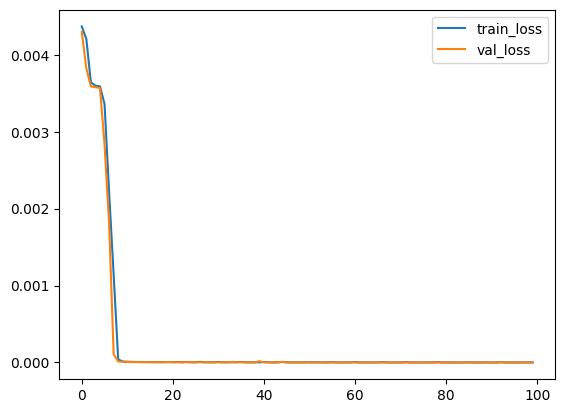

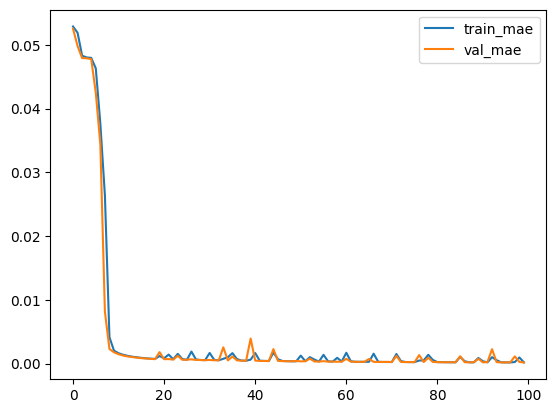

In [70]:
# Кривые обучения
history_df = pd.DataFrame(history)
history_df.loc[:, ['train_loss', 'val_loss']].plot()
history_df.loc[:, ['train_mae', 'val_mae']].plot()

In [103]:
# загрузка лучшей модели
model = LSTM_Autoencoder(embedding_dim=32).to(device)
model.load_state_dict(torch.load('saved_models/best_lstm-ae_cwru.pth'))
threshold_results, best_threshold = find_optimal_threshold_lstm(model, val_threshold_loader, y_val_threshold)
threshold_results.sort_values('fbeta', ascending=False)

,percentile,threshold,precision,recall,f1,fbeta
5,99.9,6.310088e-07,0.999121,1.0,0.999560,0.999824
4,99.5,4.149109e-07,0.997368,1.0,0.998682,0.999473
3,99.0,3.713362e-07,0.995622,1.0,0.997806,0.999121
2,98.0,2.597163e-07,0.991282,1.0,0.995622,0.998244
1,97.0,2.419268e-07,0.986979,1.0,0.993447,0.997368
0,95.0,2.057803e-07,0.978485,1.0,0.989126,0.995622


In [104]:
# Выбранный порог 6.310088e-07
threshold = 6.310088e-07
test_errors, test_predictions, test_metrics = compute_reconstruction_error_lstm(
    model, 
    test_loader_lstm,
    threshold)

print("\nTest scores:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f'F-beta score: {test_metrics['fbeta']:.4f}')


Test scores:
Precision: 0.9994
Recall: 1.0000
F1-score: 0.9997
F-beta score: 0.9999


In [106]:
# Дополнительное тестирование обобщения другой модели
model = LSTM_Autoencoder(embedding_dim=32).to(device)
model.load_state_dict(torch.load('saved_models/best_lstm-ae_ims.pth')) # другая модель
test_errors, test_predictions, test_metrics = compute_reconstruction_error_lstm(
    model, 
    test_loader_lstm,
    1.478834e-08) # Порог той модели

print("Test scores:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f'F-beta score: {test_metrics['fbeta']:.4f}')

Test scores:
Precision: 0.9988
Recall: 1.0000
F1-score: 0.9994
F-beta score: 0.9998


## Дополнительная оценка моделей

### Оценка устойчивости к выбору порога срабатывания (PR-curve)

In [121]:
iso_forest = IsolationForest(
    contamination=0.01,
    random_state=0,
    max_features =0.5,
    bootstrap=False,
    max_samples=0.7,
    n_estimators=100
)

iso_forest.fit(X_train_pca)
scores_if = -iso_forest.decision_function(X_test_pca)

In [122]:
ocsvm = OneClassSVM(gamma=0.001, kernel='rbf', nu=0.01)

ocsvm.fit(X_train_pca)
scores_ocsvm = -ocsvm.decision_function(X_test_pca)

In [129]:
model = Autoencoder(len(X_train_pca[0])).to(device)
model.load_state_dict(torch.load('saved_models/best_ae_cwru.pth'))
threshold = 1.453361
AE_err, _, _ = compute_reconstruction_error(model, test_loader, threshold)

In [130]:
precision, recall, _ = precision_recall_curve(y_test, scores_if, pos_label=-1)
precision_ocsvm, recall_ocsvm, _ = precision_recall_curve(y_test, scores_ocsvm, pos_label=-1)
precision_ae, recall_ae, _ = precision_recall_curve(y_test, AE_err, pos_label=-1)

In [131]:
model_lstm = LSTM_Autoencoder(embedding_dim=32).to(device)
model_lstm.load_state_dict(torch.load('saved_models/best_lstm-ae_cwru.pth'))
threshold_lstm = 0.006317
lstmAE_err, _, _ = compute_reconstruction_error_lstm(model_lstm, test_loader_lstm, threshold_lstm)
precision_lstmae, recall_lstmae, _ = precision_recall_curve(y_test_lstm, lstmAE_err)

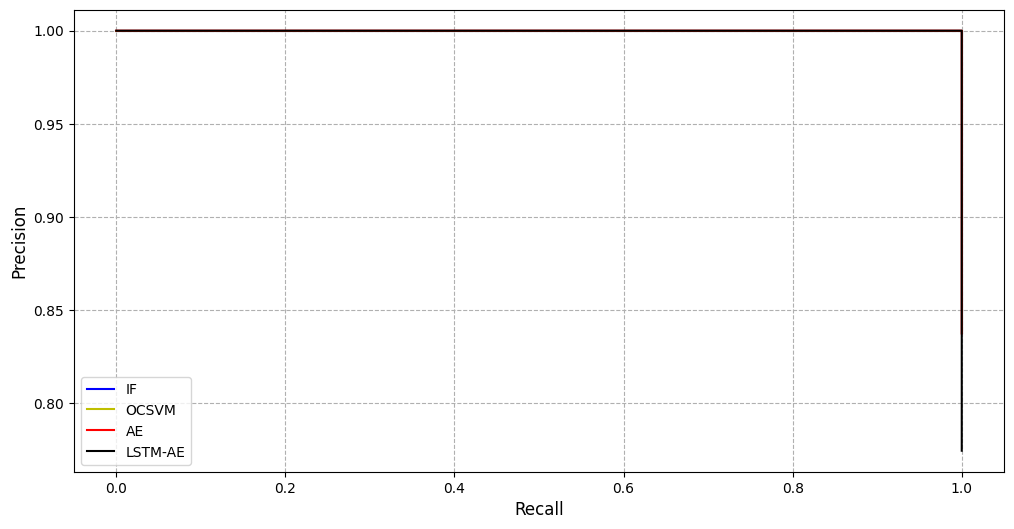

In [132]:
plt.figure(figsize=(12, 6))

plt.plot(recall, precision, 'b-', linewidth=1.5, label='IF')
plt.plot(recall_ocsvm, precision_ocsvm, 'y-', linewidth=1.5, label='OCSVM')
plt.plot(recall_ae, precision_ae, 'r-', linewidth=1.5, label='AE')
plt.plot(recall_lstmae, precision_lstmae, 'k-', linewidth=1.5, label='LSTM-AE')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.grid(True, linestyle='--')
plt.legend(loc='best')
plt.show()

### ROC-CURVE, ROC-AUC

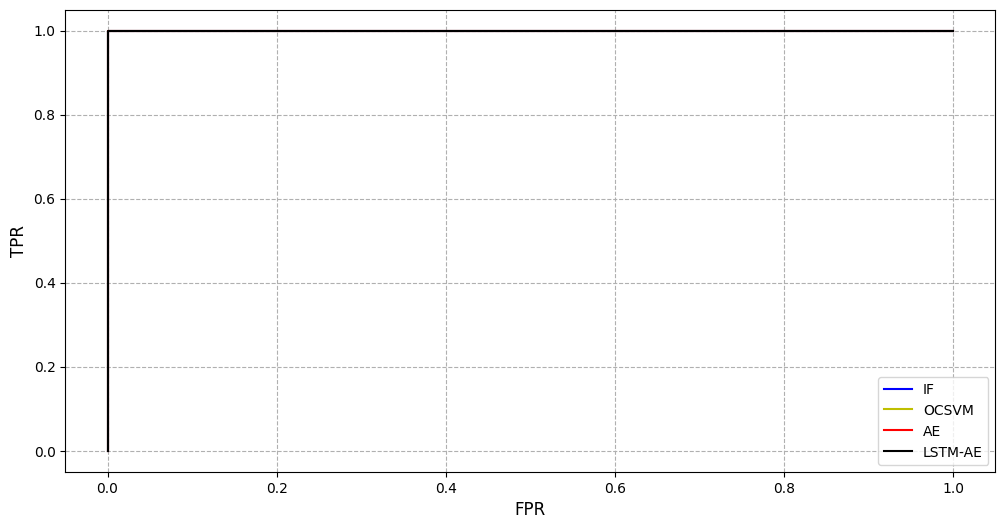

In [133]:
fpr_if, tpr_if, _ = roc_curve(y_test, scores_if, pos_label=-1)
fpr_ocsvm, tpr_ocsvm, _ = roc_curve(y_test, scores_ocsvm, pos_label=-1)
fpr_ae, tpr_ae, _ = roc_curve(y_test, AE_err, pos_label=-1)
fpr_lstmaae, tpr_lstmaae, _ = roc_curve(y_test_lstm, lstmAE_err)

plt.figure(figsize=(12, 6))

plt.plot(fpr_if, tpr_if, 'b-', linewidth=1.5, label='IF')
plt.plot(fpr_ocsvm, tpr_ocsvm, 'y-', linewidth=1.5, label='OCSVM')
plt.plot(fpr_ae, tpr_ae, 'r-', linewidth=1.5, label='AE')
plt.plot(fpr_lstmaae, tpr_lstmaae, 'k-', linewidth=1.5, label='LSTM-AE')
plt.xlabel('FPR', fontsize=12)
plt.ylabel('TPR', fontsize=12)
plt.grid(True, linestyle='--')
plt.legend(loc='best')
plt.show()

In [134]:
y_true_bin = np.where(y_test == -1, 1, 0)
print(f'ROC AUC для IF: {roc_auc_score(y_true_bin, scores_if)}')
print(f'ROC AUC для OCSVM: {roc_auc_score(y_true_bin, scores_ocsvm)}')
print(f'ROC AUC для AE: {roc_auc_score(y_true_bin, AE_err)}')
print(f'ROC AUC для LSTM-AE: {roc_auc_score(y_test_lstm, lstmAE_err)}')

ROC AUC для IF: 1.0
ROC AUC для OCSVM: 1.0
ROC AUC для AE: 1.0
ROC AUC для LSTM-AE: 1.0


# IMS

## Load and split data

In [2]:
df_ims = pd.read_csv('IMS/processed_features/all_features.csv')
df_ims

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs,meta_fidx
0,0.004505,0.061131,0.061297,0.185451,0.370243,0.096978,-0.110093,1.147976,1.597009,1980.562322,...,0.455489,0.249309,0.334615,0.085152,0.025490,1.505809e-05,0.025490,0.191953,0.100116,0
1,0.001797,0.065093,0.065118,0.219021,0.405815,0.041413,0.102433,1.200407,1.704245,2224.859022,...,0.561866,0.301271,0.397611,0.088648,0.027786,-1.084516e-05,0.027786,0.191953,0.100116,0
2,0.000733,0.065384,0.065388,0.219021,0.414781,-0.010965,0.094662,1.215419,1.703401,2241.954647,...,0.561866,0.301271,0.295183,0.062275,0.023941,1.627292e-05,0.023941,0.172951,0.091079,0
3,-0.000989,0.070505,0.070512,0.270222,0.480579,-0.112812,0.482162,1.278002,1.859837,2607.249240,...,0.493042,0.266535,0.311963,0.055998,0.024612,5.902344e-05,0.024612,0.167517,0.089519,0
4,-0.001056,0.068104,0.068112,0.270222,0.480579,-0.101927,0.643559,1.254486,1.782690,2432.879505,...,0.502709,0.266535,0.319387,0.052699,0.024903,-4.225840e-05,0.024903,0.161032,0.089519,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38371,0.000002,0.000824,0.000824,0.003076,0.005252,0.747529,-0.753403,0.010687,0.024105,0.355962,...,0.002679,0.001410,0.000013,0.018249,0.000158,-3.854591e-07,0.000158,0.001309,0.000664,983
38372,0.000001,0.000800,0.000800,0.003076,0.003997,0.921013,-0.517156,0.010745,0.023248,0.335842,...,0.003050,0.001584,0.000013,0.020074,0.000162,1.403137e-07,0.000162,0.001309,0.000664,983
38373,0.000031,0.000790,0.000791,0.001801,0.002737,0.845308,-0.819768,0.010886,0.022870,0.328475,...,0.003150,0.001584,0.000012,0.018604,0.000153,-1.486240e-07,0.000153,0.001282,0.000666,983
38374,0.000007,0.000811,0.000811,0.002253,0.004054,0.683679,-0.950959,0.011087,0.023460,0.344728,...,0.003095,0.001566,0.000016,0.022600,0.000176,5.797870e-08,0.000176,0.001441,0.000736,983


Для обучающей выборки возьмём первые 500 файлов.

In [3]:
train_mask_ims = df_ims['meta_fidx'] < 500
train_df_ims = df_ims[train_mask_ims].copy()
# val and test
temp_df_ims = df_ims[~train_mask_ims].copy()

train_df_ims.tail(5)

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs,meta_fidx
19495,0.002593,0.067771,0.067821,0.243046,0.469403,-0.101586,0.177154,1.252749,1.774134,2415.068466,...,0.519131,0.290032,0.445224,0.091083,0.029403,-0.000014,0.029403,0.261303,0.135673,499
19496,-0.003782,0.068260,0.068365,0.254278,0.497324,-0.190413,0.168157,1.310504,1.755887,2457.886279,...,0.637109,0.347076,0.578336,0.117512,0.033511,0.000010,0.033511,0.261303,0.135673,499
19497,-0.003320,0.070957,0.071035,0.254278,0.505973,0.008431,0.174481,1.302740,1.865803,2651.317370,...,0.634450,0.347076,0.593269,0.110352,0.033941,0.000029,0.033941,0.230288,0.118698,499
19498,0.002477,0.073591,0.073632,0.251695,0.461018,0.029650,-0.103639,1.418772,1.882870,2845.755031,...,0.595398,0.308023,0.566383,0.086851,0.033163,0.000069,0.033163,0.226424,0.115376,499
19499,0.001180,0.067999,0.068009,0.233115,0.455688,-0.050490,-0.152673,1.277445,1.762342,2425.709853,...,0.507400,0.308023,0.409598,0.078622,0.028202,0.000021,0.028202,0.218528,0.115376,499


In [4]:
temp_df_ims.head(5)

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs,meta_fidx
19500,-0.013376,0.069559,0.070833,0.217027,0.421724,0.163908,0.099357,1.340077,1.877538,2724.328306,...,0.524953,0.273729,0.456994,0.084746,0.029789,-0.000026,0.029789,0.183617,0.092823,500
19501,-0.000874,0.074810,0.074815,0.235916,0.459754,-0.006946,0.073090,1.395427,1.945546,2934.971200,...,0.633385,0.364290,0.570361,0.095182,0.033279,0.000097,0.033279,0.211688,0.113252,500
19502,0.005440,0.072229,0.072434,0.238384,0.474300,-0.014066,0.150869,1.308563,1.921074,2766.267040,...,0.633385,0.364290,0.479558,0.084770,0.030515,-0.000039,0.030515,0.211688,0.113252,500
19503,0.002144,0.068340,0.068373,0.238384,0.398999,0.158482,-0.185995,1.253094,1.794874,2453.410336,...,0.484348,0.256427,0.441986,0.089700,0.029295,-0.000004,0.029295,0.201545,0.104296,500
19504,-0.001890,0.067540,0.067566,0.227806,0.395340,0.190432,-0.075023,1.300398,1.728396,2395.333246,...,0.459912,0.256427,0.413296,0.087626,0.028329,-0.000016,0.028329,0.201545,0.104296,500


In [5]:
# Для начала разметим данные. С 700 файла аномальное состояние
# Как и раньше: 1 - норма, -1 - аномалия.
temp_df_ims['target'] = 1
anomaly_mask = temp_df_ims['meta_fidx'] >= 700
temp_df_ims.loc[anomaly_mask, 'target'] = -1

# Делим на val и test
# В этом случае более ленивый способ, просто перемешиваем 
# и делим 20% и 80% для валидационной и тестовой соответственно
temp_shuffled = shuffle(temp_df_ims, random_state=0)
split_idx = round(len(temp_shuffled) * 0.2)
val_df_ims = temp_shuffled.iloc[:split_idx].copy()
test_df_ims = temp_shuffled.iloc[split_idx:].copy()

In [6]:
# Формируем X и y
# Обучающая выборка - только нормальные
X_train_ims = train_df_ims.drop(columns='meta_fidx')

# Валидационная
X_val_ims = val_df_ims.drop(columns=['meta_fidx', 'target'])
y_val_ims = val_df_ims['target'].copy()

# Тестовая
X_test_ims = test_df_ims.drop(columns=['meta_fidx', 'target'])
y_test_ims = test_df_ims['target'].copy()

In [7]:
# Оценка баланса классов в тестовой выборке (более сбалансированная)
np.unique(y_test_ims, return_counts=True)

(array([-1,  1]), array([8861, 6240]))

In [8]:
# Нормализованные
feature_scaler_ims = StandardScaler()

X_train_ims_scaled = feature_scaler_ims.fit_transform(X_train_ims)
X_val_ims_scaled = feature_scaler_ims.transform(X_val_ims)
X_test_ims_scaled = feature_scaler_ims.transform(X_test_ims)

In [9]:
# PCA (с 0.95 дисперсией)
pca = PCA(n_components=0.95, random_state=0)

X_train_pca = pca.fit_transform(X_train_ims_scaled)
X_val_pca = pca.transform(X_val_ims_scaled)
X_test_pca = pca.transform(X_test_ims_scaled)

In [10]:
pca.n_components_

np.int64(18)

In [11]:
sum(pca.explained_variance_ratio_)

np.float64(0.9605799501044154)

# Isolation Forest

In [65]:
iso_forest = IsolationForest(random_state=0)

iso_forest.fit(X_train_pca)

test_predictions = iso_forest.predict(X_test_pca)

print("Test scores:")
print(f"F1-score: {f1_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Precision: {precision_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test_ims, test_predictions, beta=2.0, pos_label=-1):.4f}')

Test scores:
F1-score: 0.8360
Precision: 0.7183
Recall: 0.9998
F-beta score: 0.9271


### Подбор гиперпараметров:

In [66]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': ['auto', 0.5, 0.7],
    'contamination': [0.01, 0.05, 0.1, 0.15, 'auto'],
    'max_features': [0.5, 0.7, 1.0],
    'bootstrap': [False, True]
}

results = []

for params in tqdm(ParameterGrid(param_grid)):
    iso_forest = IsolationForest(random_state=0, **params)
    iso_forest.fit(X_train_pca)

    val_pred = iso_forest.predict(X_val_pca)

    f1 = f1_score(y_val_ims, val_pred, pos_label=-1)
    precision = precision_score(y_val_ims, val_pred, pos_label=-1)
    recall = recall_score(y_val_ims, val_pred, pos_label=-1)
    fbeta = fbeta_score(y_val_ims, val_pred, beta=2.0, pos_label=-1)

    results.append({
        **params,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'fbeta': fbeta
    })

# Сортируем результаты
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('fbeta', ascending=False)
results_df.head(10)

  0%|          | 0/270 [00:00<?, ?it/s]

,bootstrap,contamination,max_features,max_samples,n_estimators,f1,precision,recall,fbeta
9,False,0.01,0.7,auto,100,0.905194,0.832765,0.991422,0.955032
120,False,auto,0.7,0.5,100,0.893703,0.810206,0.996388,0.952607
144,True,0.01,0.7,auto,100,0.907993,0.842410,0.984650,0.952485
154,True,0.01,1.0,auto,200,0.898586,0.822581,0.990068,0.951327
0,False,0.01,0.5,auto,100,0.896327,0.817877,0.991422,0.951061
134,False,auto,1.0,0.7,300,0.892445,0.809331,0.994582,0.951045
133,False,auto,1.0,0.7,200,0.892944,0.810453,0.994131,0.951024
2,False,0.01,0.5,auto,300,0.901443,0.829602,0.986907,0.950848
135,True,0.01,0.5,auto,100,0.902585,0.832824,0.985102,0.950348
1,False,0.01,0.5,auto,200,0.898521,0.824350,0.987359,0.949796


In [67]:
iso_forest = IsolationForest(random_state=0, bootstrap=False, contamination=0.01, max_features=0.7, max_samples='auto', n_estimators=100)

iso_forest.fit(X_train_pca)

test_predictions = iso_forest.predict(X_test_pca)

print("Test scores:")
print(f"F1-score: {f1_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Precision: {precision_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test_ims, test_predictions, beta=2.0, pos_label=-1):.4f}')

Test scores:
F1-score: 0.9102
Precision: 0.8400
Recall: 0.9933
F-beta score: 0.9583


# OCSVM

In [68]:
ocsvm = OneClassSVM()

ocsvm.fit(X_train_pca)
test_predictions = ocsvm.predict(X_test_pca)

print("Test scores:")
print(f"F1-score: {f1_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Precision: {precision_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test_ims, test_predictions, beta=2.0, pos_label=-1):.4f}')

Test scores:
F1-score: 0.7574
Precision: 0.6095
Recall: 1.0000
F-beta score: 0.8864


### Подбор гиперпараметров:

In [69]:
# Только rbf ядро
param_grid_rbf = {
    'kernel': ['rbf'],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
}

# Только poly ядро
param_grid_poly = {
    'kernel': ['poly'],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'degree': [3, 4, 5],
    'coef0': [0.0, 0.1, 0.5],
}

# Только sigmoid ядро
param_grid_sigmoid = {
    'kernel': ['sigmoid'],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'coef0': [0.0, 0.1],
}

param_grid_ocsvm = [param_grid_rbf, param_grid_poly, param_grid_sigmoid]

results_ocsvm = []

for params in tqdm(ParameterGrid(param_grid_ocsvm)):
    ocsvm = OneClassSVM(**params)
    ocsvm.fit(X_train_pca)

    val_pred = ocsvm.predict(X_val_pca)

    f1 = f1_score(y_val_ims, val_pred, pos_label=-1)
    precision = precision_score(y_val_ims, val_pred, pos_label=-1)
    recall = recall_score(y_val_ims, val_pred, pos_label=-1)
    fbeta = fbeta_score(y_val_ims, val_pred, beta=2.0, pos_label=-1)

    results_ocsvm.append({
        **params,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'fbeta': fbeta
    })

# Сортируем результаты
results_ocsvm_df = pd.DataFrame(results_ocsvm)
results_ocsvm_df = results_ocsvm_df.sort_values('fbeta', ascending=False)

  0%|          | 0/300 [00:00<?, ?it/s]

In [70]:
results_ocsvm_df.head(5)

,gamma,kernel,nu,f1,precision,recall,fbeta,coef0,degree
296,0.001,sigmoid,0.05,0.886401,0.807193,0.982844,0.941853,0.1,NaN
273,0.001,sigmoid,0.20,0.847876,0.740641,0.991422,0.928541,0.0,NaN
272,0.001,sigmoid,0.10,0.894098,0.846651,0.947178,0.925207,0.0,NaN
297,0.001,sigmoid,0.10,0.823726,0.700285,1.000000,0.921151,0.1,NaN
20,0.001,rbf,0.01,0.814120,0.686725,0.999549,0.916087,NaN,NaN


In [71]:
ocsvm = OneClassSVM(coef0=0.1, gamma=0.001, kernel='sigmoid', nu=0.05)

ocsvm.fit(X_train_pca)

test_predictions = ocsvm.predict(X_test_pca)

print("Test scores:")
print(f"F1-score: {f1_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Precision: {precision_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f"Recall: {recall_score(y_test_ims, test_predictions, pos_label=-1):.4f}")
print(f'F-beta score: {fbeta_score(y_test_ims, test_predictions, beta=2.0, pos_label=-1):.4f}')

Test scores:
F1-score: 0.8902
Precision: 0.8148
Recall: 0.9809
F-beta score: 0.9425


## Autoencoder

In [15]:
# Разделяем обучающие данные на train (80%) и validation (20%)
X_train_normal, X_val_normal = train_test_split(
    X_train_pca, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

# datasets and dataloaders
train_dataset = TensorDataset(torch.FloatTensor(X_train_normal))
val_dataset = TensorDataset(torch.FloatTensor(X_val_normal))
test_dataset = TensorDataset(torch.FloatTensor(X_test_pca), torch.LongTensor(np.array(y_test_ims)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [22]:
# Создание модели и её обучение
model = Autoencoder(len(X_train_pca[0])).to(device)
criterion = nn.MSELoss()
criterion_mae = nn.L1Loss()
optimizer = optim.Adam(model.parameters())

history = {
    'train_loss': [], 'train_mae': [],
    'val_loss': [], 'val_mae': []
}

# Early Stopping
best_val_loss = float('inf')
patience_counter = 0
patience = 15

epoch_pbar = tqdm(range(100), desc='Эпохи')

for epoch in epoch_pbar:
    # train
    model.train()
    train_loss = 0.0
    train_mae = 0.0

    for batch in train_loader:
        X = batch[0].to(device)
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, X)
        mae = criterion_mae(output, X)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
        train_mae += mae.item() * X.size(0)

    train_loss /= len(train_loader.dataset)
    train_mae /= len(train_loader.dataset)
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)

    # val
    model.eval()
    val_loss = 0.0
    val_mae = 0.0

    with torch.no_grad():
        for batch in val_loader:
            X = batch[0].to(device)
            output = model(X)
            loss = criterion(output, X)
            mae = criterion_mae(output, X)

            val_loss += loss.item() * X.size(0)
            val_mae += mae.item() * X.size(0)

    val_loss /= len(val_loader.dataset)
    val_mae /= len(val_loader.dataset)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    epoch_pbar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'train_mae': f'{train_mae:.4f}',
        'val_loss': f'{val_loss:.4f}',
        'val_mae': f'{val_mae:.4f}'
    })
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'saved_models/best_ae_ims.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch+1}")
            break

Эпохи:   0%|          | 0/100 [00:00<?, ?it/s]


Ранняя остановка на эпохе 68


<Axes: >

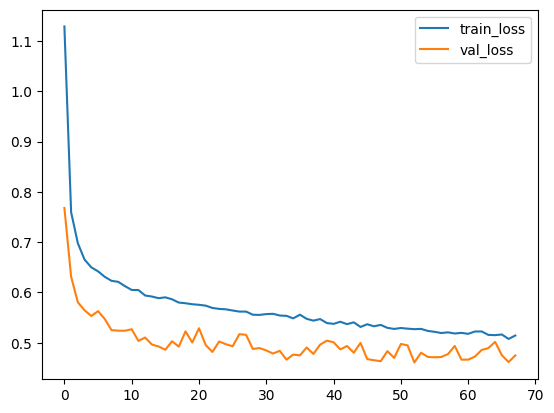

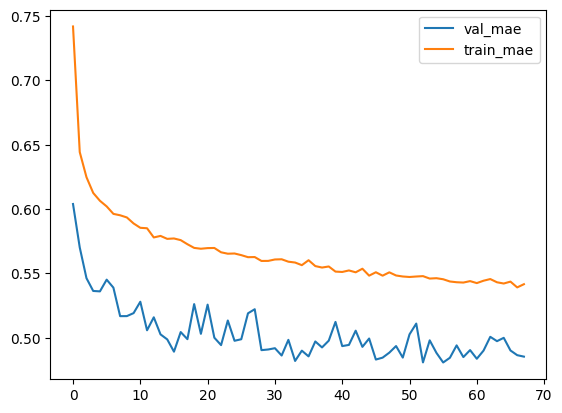

In [23]:
# Кривые обучения
history_df = pd.DataFrame(history)
history_df.loc[:, ['train_loss', 'val_loss']].plot()
history_df.loc[:, ['val_mae', 'train_mae']].plot()

In [16]:
# загрузка лучшей модели
model = Autoencoder(len(X_train_pca[0])).to(device)
model.load_state_dict(torch.load('saved_models/best_ae_ims.pth'))

<All keys matched successfully>

In [20]:
# Использование валидационной выборки для определения порога срабатывания
val1_dataset = TensorDataset(torch.FloatTensor(X_val_pca), torch.LongTensor(np.array(y_val_ims)))
val1_loader = DataLoader(val1_dataset, batch_size=32, shuffle=False)
threshold_results, best_threshold = find_optimal_threshold(model, val1_loader, y_val_ims, [75, 77.5, 80, 82.5, 85, 87.5, 90, 92.5, 95])

In [21]:
threshold_results.sort_values('fbeta', ascending=False)

,percentile,threshold,precision,recall,f1,fbeta
0,75.0,6.386875,0.842488,0.941761,0.889363,0.920078
1,77.5,8.634788,0.850000,0.897968,0.873326,0.887946
2,80.0,12.281952,0.856287,0.839278,0.847697,0.842625
3,82.5,13.817927,0.870432,0.827991,0.848681,0.836145
4,85.0,15.117465,0.885125,0.813995,0.848071,0.827292
5,87.5,16.512222,0.901565,0.806321,0.851287,0.823725
6,90.0,17.882265,0.919296,0.802257,0.856798,0.823219
7,92.5,19.445326,0.937766,0.795937,0.861050,0.820764
8,95.0,21.154642,0.957424,0.791874,0.866815,0.820239


Оценка на тестовой выборке:

In [22]:
thresold = 6.386875
test_errors, test_predictions, test_metrics = compute_reconstruction_error(
    model, 
    test_loader,
    thresold)

print("\nTest scores:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f"F-beta score: {test_metrics['fbeta']:.4f}")


Test scores:
Precision: 0.8517
Recall: 0.9489
F1-score: 0.8977
F-beta score: 0.9277


# End-to-end DL

## Preprocessing

In [55]:
def ascii_to_df_bearing1(ascii_file_path, fs=20000, verbose=False):
    """
    Чтение ASCII файла IMS Bearing Data в df, извлекая только первый канал (Bearing 1).
    """
    if verbose:
        print(f"Чтение: {ascii_file_path}")

    data_array = []

    with open(ascii_file_path, 'r', encoding='ascii') as f:
        for line in f:
            line = line.strip()
            if line:
                # Берем только первое значение (первая колонка)
                value = float(line.split('\t')[0])
                data_array.append(value)

    # Преобразуем в массив
    data_array = np.array(data_array)
    
    if len(data_array) > 0:
        if verbose:
            print(f"Загружено {len(data_array)} отсчетов")
    else:
        if verbose:
            print("Ошибка: не найден массив с данными")
        return None
    
    # Создание DataFrame
    df = pd.DataFrame({
        'Amplitude': data_array
    })
    
    return df

In [56]:
files = sorted(glob.glob('IMS/raw_ASCII/*'))
all_segments = []
all_labels = []
all_idx = []

for i, file in enumerate(files):
    # Метка от индекса файла
    if i < 700:
        label = 0
    else:
        label = 1

    df = ascii_to_df_bearing1(file)                            # Чтение
    df_filtered_signal = filter_signal(df, fs=20000)           # Фильтрация
    nd_segments = segment_signal(df_filtered_signal, fs=20000) # Сегментация
    all_segments.append(nd_segments)                           # Записываем сегменты
    all_labels.append(np.full(len(nd_segments), label))        # Записываем метки
    all_idx.append(np.full(len(nd_segments), i))               # Записываем индекс файла

# Объединение всех данных
X = np.vstack(all_segments)
y = np.hstack(all_labels)
idx = np.hstack(all_idx)

# Сохранение данных
current_path = os.path.join('IMS', 'ims_labeled.h5')
with h5py.File(current_path, 'w') as f:
    f.create_dataset('data', data=X, compression="gzip", chunks=True)
    f.create_dataset('labels', data=y, compression="gzip")
    f.create_dataset('idx', data=idx, compression="gzip")

## Выборки
Выборки сформируем аналогично CWRU.

In [26]:
with h5py.File('IMS/ims_labeled.h5', 'r') as f:
    X = f['data'][:]
    y = f['labels'][:]
print(f'X shape before: {X.shape}')
X = X.reshape(X.shape[0], X.shape[1], 1)
print(f'X shape after: {X.shape}')

X shape before: (38376, 1024)
X shape after: (38376, 1024, 1)


In [27]:
# Нормальные
X_normal = X[y == 0]
y_normal = y[y == 0]

# Аномалии
X_anomaly = X[y == 1]
y_anomaly = y[y == 1]

# Разделение норм: train+val и test+val_threshold
X_norm_train_val, X_norm_test_val, y_norm_train_val, y_norm_test_val = train_test_split(
    X_normal, y_normal, 
    train_size=0.7,
    random_state=0,
    shuffle=True
)

# 15% норм на подбор порога, 15% норма на тест
X_norm_val_threshold, X_norm_test, y_norm_val_threshold, y_norm_test = train_test_split(
    X_norm_test_val, y_norm_test_val,
    test_size=0.5, 
    random_state=0,
    shuffle=True
)

# Аномалии: 40% - подбор порога, 60% - тест
X_anom_val_threshold, X_anom_test, y_anom_val_threshold, y_anom_test = train_test_split(
    X_anomaly, y_anomaly,
    test_size=0.6,
    random_state=0,
    shuffle=True
)

# train+val -> train (80%), val (20%)
X_train, X_val_epochs, y_train, y_val_epochs = train_test_split(
    X_norm_train_val, y_norm_train_val,
    test_size=0.2,
    random_state=0,
    shuffle=True
)

# Итоговая выборка валидации порога
X_val_threshold = np.concatenate([X_norm_val_threshold, X_anom_val_threshold])
y_val_threshold = np.concatenate([y_norm_val_threshold, y_anom_val_threshold])

# Итоговая тестовая  выборка
X_test = np.concatenate([X_norm_test, X_anom_test])
y_test = np.concatenate([y_norm_test, y_anom_test])

# Проверка
print(f"Обучающая выборка:")
print(f"  - X_train: {X_train.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - Проверка классов: {np.unique(y_train, return_counts=True)}")

print(f"\nВалидационная выборка для обучения:")
print(f"  - X_val_epochs: {X_val_epochs.shape}")
print(f"  - y_val_epochs: {y_val_epochs.shape}")
print(f"  - Проверка классов: {np.unique(y_val_epochs, return_counts=True)}")

print(f"\nТестовая выборка:")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"  - Проверка классов: {np.unique(y_test, return_counts=True)}")

print(f"\nВалидационная выборка для подбора порога:")
print(f"  - X_val_threshold: {X_val_threshold.shape}")
print(f"  - y_val_threshold: {y_val_threshold.shape}")
print(f"  - Проверка классов: {np.unique(y_val_threshold, return_counts=True)}")

Обучающая выборка:
  - X_train: (15288, 1024, 1)
  - y_train: (15288,)
  - Проверка классов: (array([0]), array([15288]))

Валидационная выборка для обучения:
  - X_val_epochs: (3822, 1024, 1)
  - y_val_epochs: (3822,)
  - Проверка классов: (array([0]), array([3822]))

Тестовая выборка:
  - X_test: (10741, 1024, 1)
  - y_test: (10741,)
  - Проверка классов: (array([0, 1]), array([4095, 6646]))

Валидационная выборка для подбора порога:
  - X_val_threshold: (8525, 1024, 1)
  - y_val_threshold: (8525,)
  - Проверка классов: (array([0, 1]), array([4095, 4430]))


In [30]:
# datasets and dataloaders
train_dataset = TensorDataset(torch.FloatTensor(X_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_epochs_dataset = TensorDataset(torch.FloatTensor(X_val_epochs))
val_epochs_loader = DataLoader(val_epochs_dataset, batch_size=32, shuffle=False)

val_threshold_dataset = TensorDataset(torch.FloatTensor(X_val_threshold), torch.LongTensor(np.array(y_val_threshold)))
val_threshold_loader = DataLoader(val_threshold_dataset, batch_size=32, shuffle=False)

test_dataset_lstm = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(np.array(y_test)))
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=32, shuffle=False)

In [ ]:
# Обучение
model = LSTM_Autoencoder(embedding_dim=32).to(device)
criterion = nn.MSELoss()
criterion_mae = nn.L1Loss()
optimizer = optim.Adam(model.parameters())
history = train_model(model, criterion, criterion_mae, optimizer, 10, train_loader,
                      val_epochs_loader, device, model_path='saved_models/best_lstm-ae_ims.pth')

In [ ]:
# Кривые обучения
history_df = pd.DataFrame(history)
history_df.loc[:, ['train_loss', 'val_loss']].plot()
history_df.loc[:, ['train_mae', 'val_mae']].plot()

In [31]:
# загрузка лучшей модели
model = LSTM_Autoencoder(embedding_dim=32).to(device)
model.load_state_dict(torch.load('saved_models/best_lstm-ae_ims.pth'))

<All keys matched successfully>

In [32]:
# Определение порога
threshold_results, best_threshold = find_optimal_threshold_lstm(model, val_threshold_loader,
                                                                y_val_threshold, percentiles=[80, 82.5, 85, 87.5, 90, 92.5, 95])
threshold_results.sort_values('fbeta', ascending=False)

,percentile,threshold,precision,recall,f1,fbeta
2,85.0,1.478834e-08,0.876729,0.987359,0.928761,0.963054
3,87.5,1.747109e-08,0.894498,0.979910,0.935258,0.961547
1,82.5,1.338421e-08,0.859467,0.989842,0.920059,0.960696
0,80.0,1.205642e-08,0.842863,0.991648,0.911222,0.957832
4,90.0,2.118625e-08,0.912243,0.962077,0.936497,0.951679
5,92.5,2.716214e-08,0.931050,0.938826,0.934922,0.937261
6,95.0,3.559117e-08,0.951330,0.904515,0.927332,0.913505


In [33]:
# Выбранный порог - 1.478834e-08
threshold = 1.478834e-08
test_errors, test_predictions, test_metrics = compute_reconstruction_error_lstm(
    model, 
    test_loader_lstm,
    threshold)

print("\nTest scores:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f'F-beta score: {test_metrics['fbeta']:.4f}')


Test scores:
Precision: 0.9078
Recall: 0.9886
F1-score: 0.9465
F-beta score: 0.9713


In [151]:
# Дополнительное тестирование обобщения другой модели
model = LSTM_Autoencoder(embedding_dim=32).to(device)
model.load_state_dict(torch.load('saved_models/best_lstm-ae_cwru.pth')) # другая модель
test_errors, test_predictions, test_metrics = compute_reconstruction_error_lstm(
    model, 
    test_loader_lstm,
    6.310088e-07) # Порог той модели

print("Test scores:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f'F-beta score: {test_metrics['fbeta']:.4f}')

Test scores:
Precision: 0.6946
Recall: 0.9928
F1-score: 0.8173
F-beta score: 0.9143


## Дополнительная оценка моделей

## Чувствительность к процессу деградации

In [152]:
# Data preparation
ims_file_idx = np.array(df_ims.meta_fidx)
X_full_ims = df_ims.drop(columns='meta_fidx')
X_full_ims_scaled = feature_scaler_ims.transform(X_full_ims)
X_full_pca = pca.transform(X_full_ims_scaled)

## IF

In [153]:
# Лучшая IF-модель на IMS
iso_forest = IsolationForest(random_state=0, bootstrap=False, contamination=0.01, max_features=0.7, max_samples='auto', n_estimators=100)
iso_forest.fit(X_train_pca)
scores = -iso_forest.decision_function(X_full_pca)
df_scores = pd.DataFrame({
        'file_idx': ims_file_idx,
        'score': scores
    })
file_scores = df_scores.groupby('file_idx').mean()

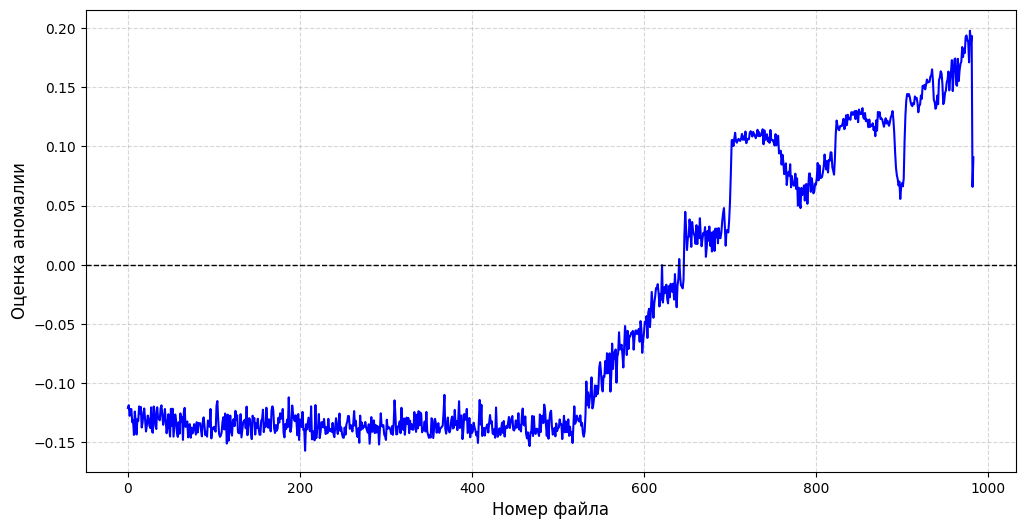

In [154]:
plt.figure(figsize=(12, 6))
    
plt.plot(file_scores.index, file_scores, 'b-', linewidth=1.5)
plt.axhline(y=0, linestyle='--', color ='k', linewidth=1)
plt.xlabel('Номер файла', fontsize=12)
plt.ylabel('Оценка аномалии', fontsize=12)
plt.grid(True, alpha=0.5, linestyle='--')

## OCSVM

In [155]:
# Лучшая OCSVM-модель на IMS
ocsvm = OneClassSVM(coef0=0.1, gamma=0.001, kernel='sigmoid', nu=0.05)
ocsvm.fit(X_train_pca)
scores_ocsvm = -ocsvm.decision_function(X_full_pca)
df_scores_ocsvm = pd.DataFrame({
        'file_idx': ims_file_idx,
        'score': scores_ocsvm
    })
file_scores_ocsvm = df_scores_ocsvm.groupby('file_idx').mean()

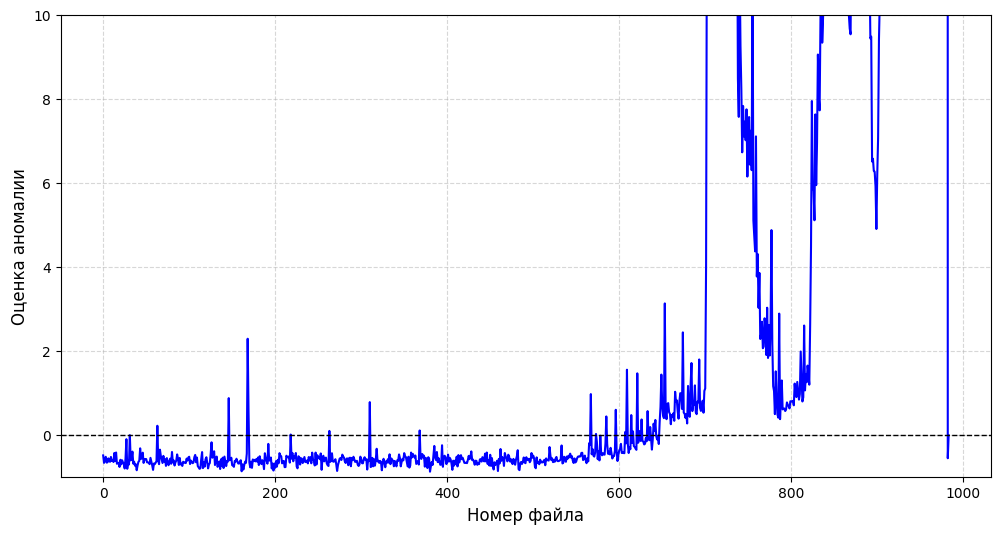

In [156]:
plt.figure(figsize=(12, 6))
    
plt.plot(file_scores_ocsvm.index, file_scores_ocsvm, 'b-', linewidth=1.5)
plt.axhline(y=0, linestyle='--', color ='k', linewidth=1)
plt.xlabel('Номер файла', fontsize=12)
plt.ylabel('Оценка аномалии', fontsize=12)
plt.ylim(-1, 10)
plt.grid(True, alpha=0.5, linestyle='--')

## AE

In [166]:
full_dataset = TensorDataset(torch.FloatTensor(X_full_pca))
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=False)
model = Autoencoder(len(X_train_pca[0])).to(device)
model.load_state_dict(torch.load('saved_models/best_ae_ims.pth'))
threshold = 21.154642
AE_err, _ = compute_reconstruction_error(model, full_loader, threshold)

In [167]:
df_scores_ae = pd.DataFrame({
        'file_idx': ims_file_idx,
        'score': AE_err
    })
file_scores_ae = df_scores_ae.groupby('file_idx').mean()

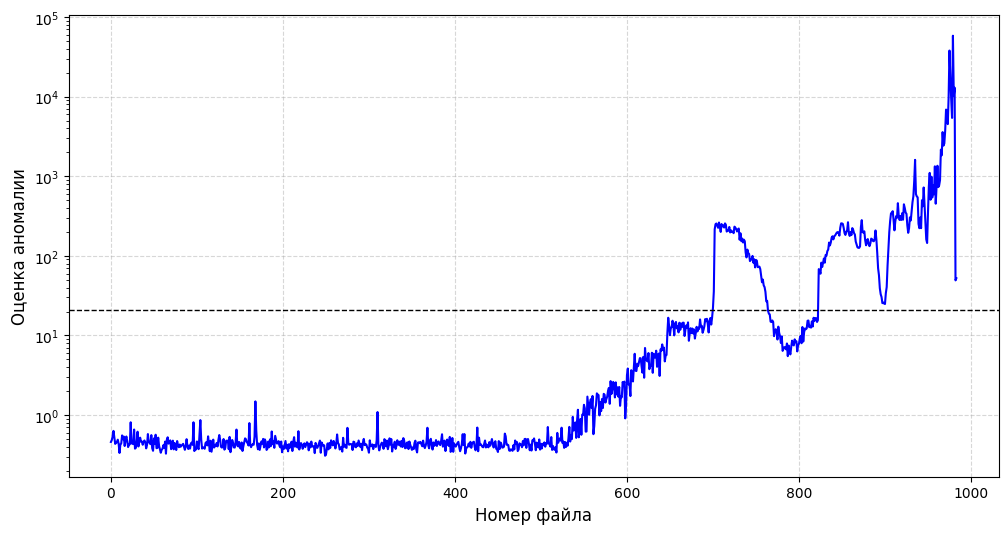

In [168]:
plt.figure(figsize=(12, 6))
    
plt.plot(file_scores_ae.index, file_scores_ae, 'b-', linewidth=1.5)
plt.axhline(y=threshold, linestyle='--', color ='k', linewidth=1)
plt.yscale('log')
plt.xlabel('Номер файла', fontsize=12)
plt.ylabel('Оценка аномалии', fontsize=12)
plt.grid(True, alpha=0.5, linestyle='--')

## LSTM-AE

In [157]:
with h5py.File('IMS/ims_labeled.h5', 'r') as f:
    X = f['data'][:]
    idx = f['idx'][:]
X = X.reshape(X.shape[0], X.shape[1], 1)
full_dataset_lstm = TensorDataset(torch.FloatTensor(X))
full_loader_lstm = DataLoader(full_dataset_lstm, batch_size=32, shuffle=False)

In [160]:
model_lstm = LSTM_Autoencoder(embedding_dim=32).to(device)
model_lstm.load_state_dict(torch.load('saved_models/best_lstm-ae_ims.pth'))
threshold_lstm = 1.478834e-08
AE_err, _ = compute_reconstruction_error_lstm(model_lstm, full_loader_lstm, threshold_lstm)
df_scores_ae = pd.DataFrame({
        'file_idx': idx,
        'score': AE_err.reshape(-1)
    })
file_scores_ae = df_scores_ae.groupby('file_idx').mean()

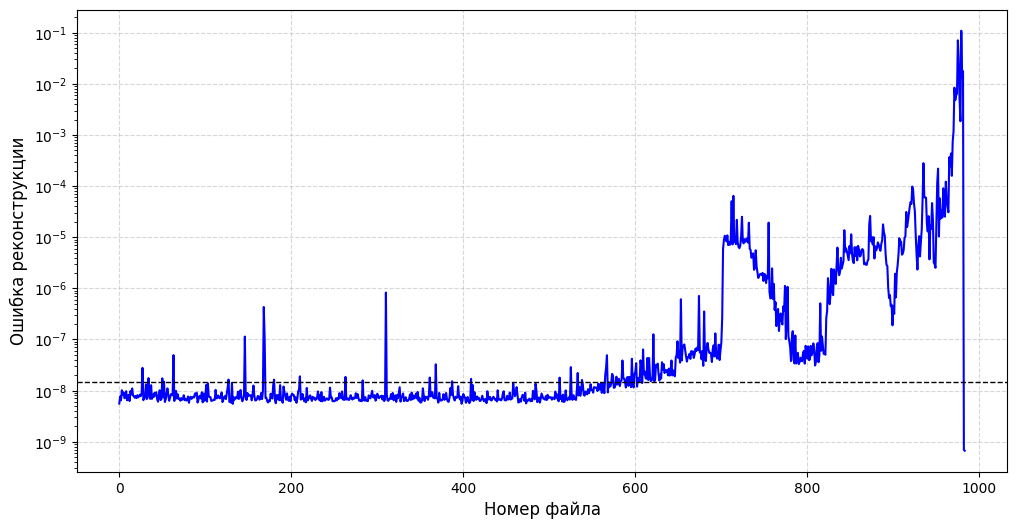

In [161]:
plt.figure(figsize=(12, 6))
    
plt.plot(file_scores_ae.index, file_scores_ae, 'b-', linewidth=1.5)
plt.axhline(y=threshold_lstm, linestyle='--', color ='k', linewidth=1)
plt.yscale('log')
plt.xlabel('Номер файла', fontsize=12)
plt.ylabel('Ошибка реконструкции', fontsize=12)
plt.grid(True, alpha=0.5, linestyle='--')

## Оценка устойчивости к выбору порога срабатывания (PR-curve)

In [169]:
scores = -iso_forest.decision_function(X_test_pca)
scores_ocsvm = -ocsvm.decision_function(X_test_pca)
AE_err, _, _ = compute_reconstruction_error(model, test_loader, threshold)
lstmAE_err, _, _ = compute_reconstruction_error_lstm(model_lstm, test_loader_lstm, threshold_lstm)

In [170]:
y_true_ims = np.where(ims_file_idx <= 700, 1, -1)
precision, recall, _ = precision_recall_curve(y_test_ims, scores, pos_label=-1)
precision_ocsvm, recall_ocsvm, _ = precision_recall_curve(y_test_ims, scores_ocsvm, pos_label=-1)
precision_ae, recall_ae, _ = precision_recall_curve(y_test_ims, AE_err, pos_label=-1)
precision_lstmae, recall_lstmae, _ = precision_recall_curve(y_test, lstmAE_err)

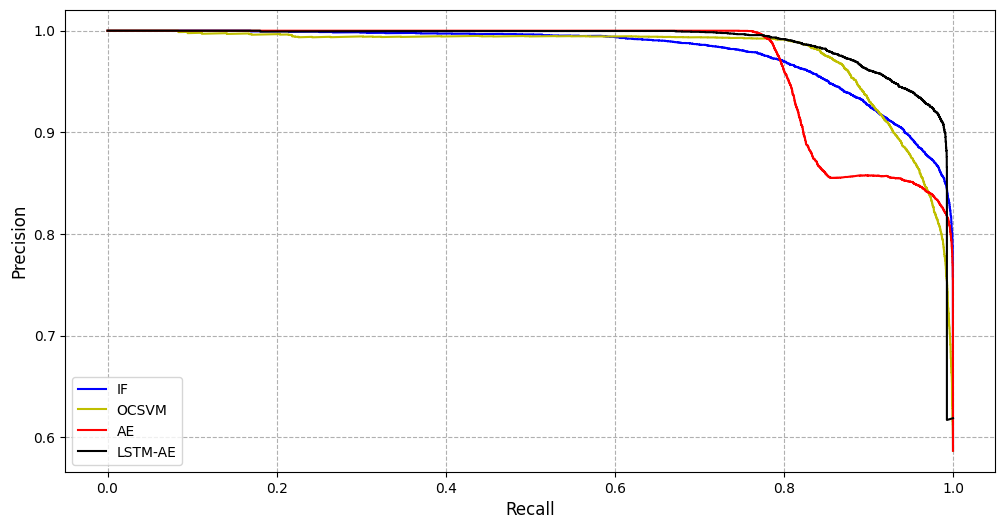

In [171]:
plt.figure(figsize=(12, 6))

plt.plot(recall, precision, 'b-', linewidth=1.5, label='IF')
plt.plot(recall_ocsvm, precision_ocsvm, 'y-', linewidth=1.5, label='OCSVM')
plt.plot(recall_ae, precision_ae, 'r-', linewidth=1.5, label='AE')
plt.plot(recall_lstmae, precision_lstmae, 'k-', linewidth=1.5, label='LSTM-AE')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.grid(True, linestyle='--')
plt.legend(loc='best')
plt.show()

# ROC-CURVE, ROC-AUC

In [172]:
fpr_if, tpr_if, _ = roc_curve(y_test_ims, scores, pos_label=-1)
fpr_ocsvm, tpr_ocsvm, _ = roc_curve(y_test_ims, scores_ocsvm, pos_label=-1)
fpr_ae, tpr_ae, _ = roc_curve(y_test_ims, AE_err, pos_label=-1)
fpr_lstmae, tpr_lstmae, _ = roc_curve(y_test, lstmAE_err)

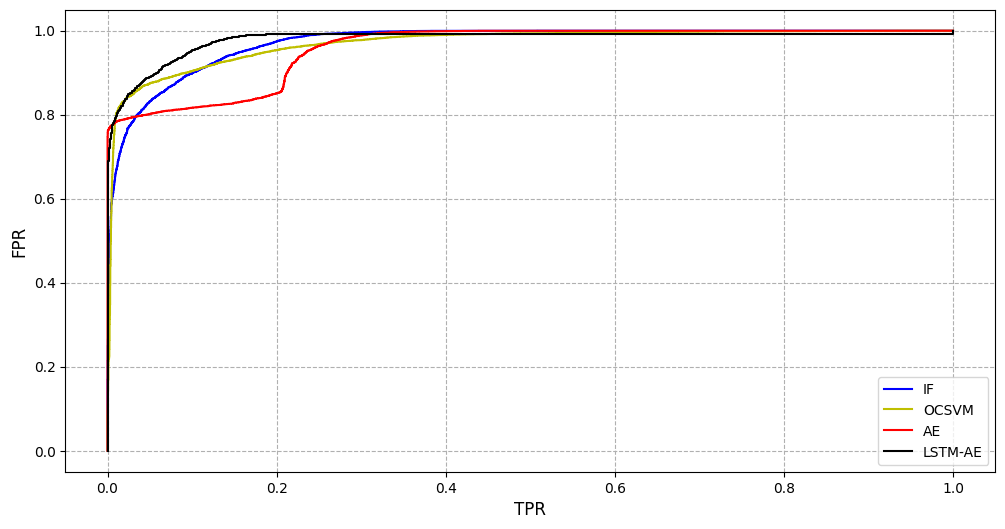

In [173]:
# Также общий график
plt.figure(figsize=(12, 6))

plt.plot(fpr_if, tpr_if, 'b-', linewidth=1.5, label='IF')
plt.plot(fpr_ocsvm, tpr_ocsvm, 'y-', linewidth=1.5, label='OCSVM')
plt.plot(fpr_ae, tpr_ae, 'r-', linewidth=1.5, label='AE')
plt.plot(fpr_lstmae, tpr_lstmae, 'k-', linewidth=1.5, label='LSTM-AE')
plt.xlabel('TPR', fontsize=12)
plt.ylabel('FPR', fontsize=12)
plt.grid(True, linestyle='--')
plt.legend(loc='best')
plt.show()

In [174]:
y_true_ims_bin = np.where(y_test_ims == -1, 1, 0)
print(f'ROC AUC для IF: {roc_auc_score(y_true_ims_bin, scores)}')
print(f'ROC AUC для OCSVM: {roc_auc_score(y_true_ims_bin, scores_ocsvm)}')
print(f'ROC AUC для AE: {roc_auc_score(y_true_ims_bin, AE_err)}')
print(f'ROC AUC для LSTM-AE: {roc_auc_score(y_test, lstmAE_err)}')

ROC AUC для IF: 0.9725864961412586
ROC AUC для OCSVM: 0.970287618749982
ROC AUC для AE: 0.9575734311112654
ROC AUC для LSTM-AE: 0.9798148619695416


Таблица с полученными результатами:

| Датасет | Модель | Версия | Precision | Recall | F1-score | Fbeta-score | ROC AUC |
|---------|--------|--------|-----------|--------|----------|-------------|---------|
|**CWRU** | IF     | Base   | 0.9949    | 1.0000 | 0.9975   | 0.9990      | -       |
|         |        | Tuned  | 0.9992    | 1.0000 | 0.9996   | 0.9998      | 1.0000  |
|         | OCSVM  | Base   | 0.9149    | 1.0000 | 0.9556   | 0.9817      | -       |
|         |        | Tuned  | 0.9977    | 1.0000 | 0.9988   | 0.9995      | 1.0000  |
|         | AE     | -      | 1.0000    | 1.0000 | 1.0000   | 1.0000      | 1.0000  |
|         |LSTM-AE | -      | 0.9994    | 1.0000 | 0.9997   | 0.9999      | 1.0000  |
| **IMS** | IF     | Base   | 0.7183    | 0.9998 | 0.8360   | 0.9271      | -       |
|         |        | Tuned  | 0.8400    | 0.9933 | 0.9102   | 0.9583      | 0.9726  |
|         | OCSVM  | Base   | 0.6095    | 1.0000 | 0.7574   | 0.8864      | -       |
|         |        | Tuned  | 0.8148    | 0.9809 | 0.8902   | 0.9425      | 0.9703  |
|         | AE     | -      | 0.8517    | 0.9489 | 0.8977   | 0.9277      | 0.9576  |
|         |LSTM-AE | -      | 0.9078    | 0.9886 | 0.9465   | 0.9713      | 0.9798  |

По итогу тестирования на двух наборах лучшей моделью является LSTM-AE. Также было произведено сравнение LSTM-моделей, обученных на разных наборах. По итогу лучшей оказалась модель, обученная на CWRU. В прототипе будет использована модель LSTM-AE, обученная на CWRU.